In [1]:
# Mount Google Colab with Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import glob
import os
import pandas as pd
import numpy as np

In [4]:
directory = "/content/drive/MyDrive/APOP 2024-25/Research/Ananya Senior Honors Project/March6_Zara_code/results/kids/"
all_files = glob.glob(os.path.join(directory, "Zara*.csv"))

print(all_files)
print("Num files:",len(all_files))

['/content/drive/MyDrive/APOP 2024-25/Research/Ananya Senior Honors Project/March6_Zara_code/results/kids/Zara_Master_Dataset_Kids_April2_12PM_2026.csv', '/content/drive/MyDrive/APOP 2024-25/Research/Ananya Senior Honors Project/March6_Zara_code/results/kids/Zara_Master_Dataset_Kids_March24_2026.csv', '/content/drive/MyDrive/APOP 2024-25/Research/Ananya Senior Honors Project/March6_Zara_code/results/kids/Zara_Master_Dataset_Kids_April2_4PM_2026.csv', '/content/drive/MyDrive/APOP 2024-25/Research/Ananya Senior Honors Project/March6_Zara_code/results/kids/Zara_Master_Dataset_Kids_April3_3PM_2026.csv', '/content/drive/MyDrive/APOP 2024-25/Research/Ananya Senior Honors Project/March6_Zara_code/results/kids/Zara_Master_Dataset_Kids_April4_430PM_2026.csv', '/content/drive/MyDrive/APOP 2024-25/Research/Ananya Senior Honors Project/March6_Zara_code/results/kids/Zara_Master_Dataset_Kids_April7_10AM_2026.csv']
Num files: 6


Combine CSV individual result files

In [9]:
'''
import pandas as pd
import glob
import os

# 1. Define the folder where your 8 Excel files are located
# Use './' if they are in the same folder as this script
path = directory + 'men_April6_415PM/'
all_files = glob.glob(os.path.join(path, "*.csv"))

# 2. Load and combine all files into one list
df_list = []

for filename in all_files:
    print(f"Reading {filename}...")
    df = pd.read_csv(filename)

    base_name = os.path.basename(filename)
    clean_name = os.path.splitext(base_name)[0]
    print(clean_name)
    cleaner_name = clean_name.split("_")
    print("_".join(cleaner_name[-2:]))
    df['Source File'] = "_".join(cleaner_name[-2:])

    df_list.append(df)

# 3. Concatenate all dataframes into one large table
combined_df = pd.concat(df_list, ignore_index=True)

# 4. Remove duplicates based on the 'Product ID' column
# 'keep=first' ensures we keep the first instance found
initial_count = len(combined_df)
combined_df.drop_duplicates(subset=['Product_ID'], keep='first', inplace=True)
final_count = len(combined_df)

# 5. Export the clean, master file
output_file = "Zara_Master_Dataset_Men_April6_415PM_2026.csv"
#combined_df.to_csv(output_file, index=False)

print("-" * 30)
print(f"✅ Process Complete!")
print(f"Total rows combined: {initial_count}")
print(f"Duplicates removed: {initial_count - final_count}")
print(f"Final unique products: {final_count}")
print(f"Master file saved as: {output_file}")
'''

'\nimport pandas as pd\nimport glob\nimport os\n\n# 1. Define the folder where your 8 Excel files are located\n# Use \'./\' if they are in the same folder as this script\npath = directory + \'men_April6_415PM/\'\nall_files = glob.glob(os.path.join(path, "*.csv"))\n\n# 2. Load and combine all files into one list\ndf_list = []\n\nfor filename in all_files:\n    print(f"Reading {filename}...")\n    df = pd.read_csv(filename)\n\n    base_name = os.path.basename(filename)\n    clean_name = os.path.splitext(base_name)[0]\n    print(clean_name)\n    cleaner_name = clean_name.split("_")\n    print("_".join(cleaner_name[-2:]))\n    df[\'Source File\'] = "_".join(cleaner_name[-2:])\n\n    df_list.append(df)\n\n# 3. Concatenate all dataframes into one large table\ncombined_df = pd.concat(df_list, ignore_index=True)\n\n# 4. Remove duplicates based on the \'Product ID\' column\n# \'keep=first\' ensures we keep the first instance found\ninitial_count = len(combined_df)\ncombined_df.drop_duplicates(s

Combine summary result csv files

In [6]:
df_list = []
id_sets = []

for filename in all_files:
    print(f"Reading {filename.split("/")[-1]}...")
    df = pd.read_csv(filename)

    base_name = os.path.basename(filename)
    clean_name = os.path.splitext(base_name)[0]
    print(clean_name)
    cleaner_name = clean_name.split("_")
    print("_".join(cleaner_name[-4:]))
    df['Source File'] = "_".join(cleaner_name[-4:])

    print(df.shape[0])

    id_sets.append(set(df['Product_ID']))
    df_list.append(df)

# 3. Find the Intersection (the IDs present in ALL sets)
common_ids = set.intersection(*id_sets)
print(f"Products in all 6 files: {len(common_ids)}")

# 4. Filter each dataframe to keep only those common IDs and combine
final_dfs = []
for df in df_list:
    filtered_df = df[df['Product_ID'].isin(common_ids)]
    final_dfs.append(filtered_df)

# 5. Combine them into one master file
combined_df = pd.concat(final_dfs, ignore_index=True)


# 3. Concatenate all dataframes into one large table
#combined_df = pd.concat(df_list, ignore_index=True)

print(len(combined_df))
print(combined_df)

Reading Zara_Master_Dataset_Kids_April2_12PM_2026.csv...
Zara_Master_Dataset_Kids_April2_12PM_2026
Kids_April2_12PM_2026
157
Reading Zara_Master_Dataset_Kids_March24_2026.csv...
Zara_Master_Dataset_Kids_March24_2026
Dataset_Kids_March24_2026
159
Reading Zara_Master_Dataset_Kids_April2_4PM_2026.csv...
Zara_Master_Dataset_Kids_April2_4PM_2026
Kids_April2_4PM_2026
158
Reading Zara_Master_Dataset_Kids_April3_3PM_2026.csv...
Zara_Master_Dataset_Kids_April3_3PM_2026
Kids_April3_3PM_2026
158
Reading Zara_Master_Dataset_Kids_April4_430PM_2026.csv...
Zara_Master_Dataset_Kids_April4_430PM_2026
Kids_April4_430PM_2026
158
Reading Zara_Master_Dataset_Kids_April7_10AM_2026.csv...
Zara_Master_Dataset_Kids_April7_10AM_2026
Kids_April7_10AM_2026
158
Products in all 6 files: 157
942
     Product_ID                                               name Category  \
0        653653    POLKA DOT PRINT TIE - Blue | ZARA United States  GENERAL   
1        653654       ANIMAL PRINT TIE - Blue | ZARA United States

Identify product types and create a column with label

In [18]:
import pandas as pd
import re

# 1. Define your Category Dictionary
# Key = The category name, Value = List of keywords to look for
clothing_map = {
    'top': ['shirt', 't-shirt', 'tee', 'polo', 'top', 'blouse', 'bodysuit', 'tank', 't-shirts', 'overshirt'],
    'bottom': ['pants', 'trousers', 'jeans', 'shorts', 'leggings', 'joggers', 'chino', 'bermuda'],
    'dress': ['dress', 'jumpsuit', 'pinafore'],
    'outerwear': ['jacket', 'coat', 'blazer', 'waistcoat', 'puffer', 'parka', 'bomber', 'trench', 'overcoat', 'sweatshirt','poncho','hoodie'],
    'knitwear': ['sweater', 'cardigan', 'jumper', 'knit'],
    'shoes': ['boots', 'shoes', 'sneakers', 'sandals', 'loafers', 'clogs','flats'],
    'accessories': ['bag', 'belt', 'hat', 'scarf', 'tie', 'jewelry', 'socks', 'perfume', 'necklace', 'cap', 'sunglasses','umbrella','bandana']
}


# 3. The Extraction Loop
def classify_name_fast(name):
    name = str(name).lower()
    for category, keywords in clothing_map.items():
        pattern = r'\b(' + '|'.join(keywords) + r')\b'
        if re.search(pattern, name):
            return category
    return 'Other'

def classify_by_last_word(name):
    # Clean name and split into words
    words = str(name).lower().split()
    if not words:
        return 'Other'

    # Get the very last word
    last_word = words[-1]

    # Check if the last word belongs to any category
    for category, keywords in clothing_map.items():
        if last_word in keywords:
            return category

    # Optional: If the last word doesn't match, check the SECOND to last word
    # (Useful for names like "Linen Shirt Dress" where 'dress' is last)
    if len(words) > 1:
        second_last = words[-2]
        for category, keywords in clothing_map.items():
            if second_last in keywords:
                return category

    return 'Other'

combined_df['product_type'] = combined_df['name'].apply(classify_name_fast)


#print(df[['name', 'clothing_type']].head())
print(combined_df.head())
print(combined_df.columns)

   Product_ID                                               name Category  \
0      653653    POLKA DOT PRINT TIE - Blue | ZARA United States  GENERAL   
1      653654       ANIMAL PRINT TIE - Blue | ZARA United States  GENERAL   
2      653650      STRIPED PRINT TIE - Blue | ZARA United States  GENERAL   
3     2326603  CROISSANT AND MATCHA TEA KEYCHAIN - Brown | ZA...  GENERAL   
4     2326611  BEAR AND HEART KEYCHAIN - Light brown | ZARA U...  GENERAL   

  colour_from_title  US_price_current_usd  US_price_original_usd  \
0              Blue                  14.9                    NaN   
1              Blue                  14.9                    NaN   
2              Blue                  14.9                    NaN   
3             Brown                  15.9                    NaN   
4       Light brown                  22.9                    NaN   

   US_discount_pct_display  US_on_sale  IN_price_current_inr  \
0                    100.0        True                 750.0   


In [19]:
print(combined_df[combined_df['product_type']=='Other']['name'])

3      CROISSANT AND MATCHA TEA KEYCHAIN - Brown | ZA...
4      BEAR AND HEART KEYCHAIN - Light brown | ZARA U...
37     LIMITED EDITION LEATHER SHOPPER - Multi-color ...
38     LIMITED EDITION LEATHER SHOPPER - Multi-color ...
104      TIZ EDT 50 ML (1.7 FL. OZ) | ZARA United States
105     CLEO EDT 50 ML (1.7 FL. OZ) | ZARA United States
187    LIMITED EDITION LEATHER SHOPPER - Multi-color ...
188    LIMITED EDITION LEATHER SHOPPER - Multi-color ...
215    CROISSANT AND MATCHA TEA KEYCHAIN - Brown | ZA...
216    BEAR AND HEART KEYCHAIN - Light brown | ZARA U...
312      TIZ EDT 50 ML (1.7 FL. OZ) | ZARA United States
313     CLEO EDT 50 ML (1.7 FL. OZ) | ZARA United States
344    LIMITED EDITION LEATHER SHOPPER - Multi-color ...
345    LIMITED EDITION LEATHER SHOPPER - Multi-color ...
453      TIZ EDT 50 ML (1.7 FL. OZ) | ZARA United States
454     CLEO EDT 50 ML (1.7 FL. OZ) | ZARA United States
458    CROISSANT AND MATCHA TEA KEYCHAIN - Brown | ZA...
459    BEAR AND HEART KEYCHAIN 

Identify materials and create boolean columns for each material

In [20]:
from collections import Counter
import re

# 1. Combine all material strings into one giant block of text
all_text = " ".join(combined_df['materials_text'].fillna('').astype(str).str.lower())

# 2. Use Regex to find only words (ignoring numbers and punctuation)
words = re.findall(r'\b[a-z]{3,}\b', all_text)

# 3. Filter out "junk" words that aren't materials
junk_words = {'outer', 'shell', 'lining', 'main', 'fabric', 'contains', 'least', 'organic', 'recycled'}
material_candidates = [w for w in words if w not in junk_words]

# 4. See the most common words
print("--- Potential Materials Found ---")
for word, count in Counter(material_candidates).most_common(20):
    print(f"{word}: {count}")

--- Potential Materials Found ---
cotton: 1947
certified: 932
polyester: 878
composition: 576
rcs: 529
grown: 399
ocs: 393
organically: 393
linen: 102
elastane: 90
with: 72
viscose: 60
and: 48
front: 42
print: 30
wool: 28
sleeves: 24
pockets: 24
modal: 24
embroidered: 18


In [21]:
target_materials = ["cotton", "polyester", "viscose", "linen", "silk", "wool", "elastane", "leather", "rcs", "ocs"]

# Clean the materials column first
combined_df['materials_text'] = combined_df['materials_text'].astype(str).str.lower()

for material in target_materials:
    # The 'r' means "raw string" (so Python doesn't get confused by the backslash)
    # \b matches the start/end of a word
    pattern = rf'\b{material}\b'

    # regex=True tells pandas to use our special boundary markers
    combined_df[f'has_{material}'] = combined_df['materials_text'].str.contains(pattern, regex=True).astype(int)

print("✅ Materials parsed with whole-word precision!")

print(combined_df)
combined_df.to_csv(directory + "MEN_results_April_6.csv")

✅ Materials parsed with whole-word precision!
     Product_ID                                               name Category  \
0        653653    POLKA DOT PRINT TIE - Blue | ZARA United States  GENERAL   
1        653654       ANIMAL PRINT TIE - Blue | ZARA United States  GENERAL   
2        653650      STRIPED PRINT TIE - Blue | ZARA United States  GENERAL   
3       2326603  CROISSANT AND MATCHA TEA KEYCHAIN - Brown | ZA...  GENERAL   
4       2326611  BEAR AND HEART KEYCHAIN - Light brown | ZARA U...  GENERAL   
..          ...                                                ...      ...   
937     4410782  COTTON AND LINEN BLEND SUIT JACKET - Ecru | ZA...  GENERAL   
938     1608780  COMFORT SUIT BLAZER - Mid-ecru | ZARA United S...  GENERAL   
939     5854758  CLOTH HOODIE COAT - Navy blue | ZARA United St...  GENERAL   
940     6825088  AGES 6-10 / MANDARIN COLLAR WOOL BLEND COAT LI...      MAN   
941     1473770  WINDPROOF AND WATER RESISTANT RECCO® SYSTEM SK...  GENERAL   

    c

In [22]:
combined_df.columns

Index(['Product_ID', 'name', 'Category', 'colour_from_title',
       'US_price_current_usd', 'US_price_original_usd',
       'US_discount_pct_display', 'US_on_sale', 'IN_price_current_inr',
       'IN_price_current_usd', 'IN_price_original_inr',
       'IN_discount_pct_display', 'IN_discount_pct_calc', 'IN_on_sale',
       'Savings_USD', 'materials_text', 'made_in', 'date', 'exchange_rate',
       'time', 'Source File', 'product_type', 'has_cotton', 'has_polyester',
       'has_viscose', 'has_linen', 'has_silk', 'has_wool', 'has_elastane',
       'has_leather', 'has_rcs', 'has_ocs'],
      dtype='object')

Calculate price gap percent

In [23]:
combined_df["price_gap_pct"] = (combined_df["US_price_current_usd"] - combined_df["IN_price_current_usd"]) / combined_df["IN_price_current_usd"]

#combined_df = combined_df.replace([np.inf, -np.inf], np.nan)
print(combined_df["price_gap_pct"])
print(combined_df["IN_price_current_usd"].isna().sum())
print(combined_df["US_price_current_usd"].isna().sum())

0      0.848635
1      0.848635
2      0.848635
3      0.741512
4           NaN
         ...   
937    0.313416
938    0.316223
939    0.313416
940         NaN
941         NaN
Name: price_gap_pct, Length: 942, dtype: float64
308
0


In [24]:
# 1. Identify the "Naughty List"
# We look for rows where the price is missing (isna),
# then we grab the Product_IDs for those rows.
naughty_list = combined_df[combined_df['price_gap_pct'].isna()]['Product_ID'].unique()

# 2. Filter the main data
# The ~ symbol means "NOT".
# So this says: "Keep rows where the Product_ID is NOT in our naughty list."
combined_df = combined_df[~combined_df['Product_ID'].isin(naughty_list)]
print(df.columns)
# 3. Check how many products you lost
original_count = df['Product_ID'].nunique()
new_count = combined_df['Product_ID'].nunique()

print(f"Removed {original_count - new_count} incomplete products.")
print(f"Remaining products: {new_count}")

Index(['Product_ID', 'name', 'Category', 'colour_from_title',
       'US_price_current_usd', 'US_price_original_usd',
       'US_discount_pct_display', 'US_on_sale', 'IN_price_current_inr',
       'IN_price_current_usd', 'IN_price_original_inr',
       'IN_discount_pct_display', 'IN_discount_pct_calc', 'IN_on_sale',
       'Savings_USD', 'materials_text', 'made_in', 'date', 'exchange_rate',
       'time', 'Source File'],
      dtype='object')
Removed 57 incomplete products.
Remaining products: 101


Avg Price Gap per Material

In [25]:
print(combined_df.shape[0])
# 1. Create a list to store our findings
material_impact = []

for material in target_materials:
    column_name = f'has_{material}'

    # 2. Find only the rows that HAVE this material
    avg_gap = combined_df[combined_df[column_name] == 1]['price_gap_pct'].mean()

    material_impact.append({'Material': material, 'Avg_Price_Gap': avg_gap})

# 3. Put it in a table and sort it
impact_df = pd.DataFrame(material_impact).sort_values(by='Avg_Price_Gap', ascending=False)

print("\n--- Average Price Gap by Material ---")
print(impact_df)


606

--- Average Price Gap by Material ---
    Material  Avg_Price_Gap
6   elastane       0.714720
0     cotton       0.649925
9        ocs       0.638406
2    viscose       0.626317
8        rcs       0.605696
1  polyester       0.601203
3      linen       0.402796
5       wool       0.316609
4       silk            NaN
7    leather            NaN


Plot price changes per product ID

In [26]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_product_trend(product_id):
    # 1. Pull out only the rows for this specific item
    item_data = combined_df[combined_df['Product_ID'] == product_id]

    if item_data.empty:
        print(f"Sorry, I couldn't find '{product_id}' in the data.")
        return
    elif item_data['US_price_current_usd'].nunique() > 1:

      # 2. Set up the "Paper"
      plt.figure(figsize=(10, 5))

      # 3. Draw the line (Date on the bottom, Price on the side)
      plt.plot(item_data['date'], item_data['US_price_current_usd'],
              marker='o', linestyle='-', color='blue', linewidth=2)

      # 4. Add labels
      plt.title(f"7-Day Price Trend: {product_id}", fontsize=14)
      plt.xlabel("Date")
      plt.ylabel("Price (USD)")
      plt.grid(True, linestyle='--', alpha=0.6)

      # 5. Rotate dates so they don't overlap
      plt.xticks(rotation=45)
      plt.tight_layout()

      # 6. Show it!
      plt.show()

    #else:
    #  print(f"No price change for {product_id}")
    #  print(item_data['US_price_current_usd'])

# --- HOW TO USE IT ---
# Just type the name of one dress or shirt here:


# 1. Turn the date column into "real" dates
combined_df['date'] = pd.to_datetime(combined_df['date'])

# 2. Sort the data by date so the lines connect in the right order
combined_df = combined_df.sort_values('date')

#plot_product_trend("SATIN EFFECT DRESS")

# Get a list of every product ID
all_products = combined_df['Product_ID'].unique()
print(len(all_products))

# Look at all one by one
for i in range(len(all_products)):
    plot_product_trend(all_products[i])



101


In [27]:
df = combined_df
print(df.columns)
print(len(df))

Index(['Product_ID', 'name', 'Category', 'colour_from_title',
       'US_price_current_usd', 'US_price_original_usd',
       'US_discount_pct_display', 'US_on_sale', 'IN_price_current_inr',
       'IN_price_current_usd', 'IN_price_original_inr',
       'IN_discount_pct_display', 'IN_discount_pct_calc', 'IN_on_sale',
       'Savings_USD', 'materials_text', 'made_in', 'date', 'exchange_rate',
       'time', 'Source File', 'product_type', 'has_cotton', 'has_polyester',
       'has_viscose', 'has_linen', 'has_silk', 'has_wool', 'has_elastane',
       'has_leather', 'has_rcs', 'has_ocs', 'price_gap_pct'],
      dtype='object')
606


Fair Price Model

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Remove duplicates

# 1. Sort by date so we know which one is the "latest"
combined_df = combined_df.sort_values('date', ascending=False)

# 2. Keep only the FIRST row for each Product_ID
# This throws away the other 6 days for every item
combined_df = combined_df.drop_duplicates(subset=['Product_ID'], keep='first')

# Now use df_unique to train your model!
print(combined_df.shape[0])
# df_clean = combined_df.dropna()
combined_df.dropna(subset=['made_in'],inplace=True)
print(combined_df.shape[0])

naughty_list = combined_df[combined_df['colour_from_title'].isna()]
print("naughty list:",len(naughty_list))




#X = df.drop(columns=["price_gap_pct", "Product_ID", "name", "date"])

# Drop the target, the IDs, the names, and ALL price info
price_columns = [col for col in df.columns if "price" in col.lower()]
# X = df.drop(columns=[
#     "price_gap_pct",
#     "Product_ID",
#     "name",
#     "date"
# ] + price_columns)

X = combined_df.drop(columns=['US_price_original_usd', 'US_discount_pct_display', 'US_on_sale',"exchange_rate","price_gap_pct","date", "IN_price_current_usd", "Product_ID", "name", "IN_price_current_inr", "IN_price_original_inr", "IN_discount_pct_display", "IN_discount_pct_calc","IN_on_sale","Savings_USD", "materials_text","Source File","time"])
y = combined_df["IN_price_current_usd"]

print("X columns:", X.columns)
print("y column:", y.name)

numeric_features = X.select_dtypes(include=[np.number, "bool"]).columns.tolist()
categorical_features = [c for c in X.columns if c not in numeric_features]

print("numerical features:", numeric_features)
print("categorical features:", categorical_features)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

print(categorical_transformer)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

#print(X.head())
#print(X.tail())
#print(y.name)
#X.to_csv("X_preprocessed_data_train_test.csv")
#y.to_csv("y_preprocessed_data_train_test.csv")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# print("X training:\n",X_train)
# print("X test:\n", X_test)
# print("y_train:\n", y_train)
# print("y_test:\n", y_test)


model.fit(X_train, y_train)
pred = model.predict(X_test)

#for i in range(len(y_test)):
#  print(X_test.iloc[i,0:7], y_test.iloc[i], "\t",pred[i])

mae = mean_absolute_error(y_test, pred)
rmse = mean_squared_error(y_test, pred) ** 0.5
r2 = r2_score(y_test, pred)

print("Rows used:", len(combined_df))
print("Target:", y.name)
print("MAE:", round(mae, 4))
print("RMSE:", round(rmse, 4))
print("R^2:", round(r2, 4))


# Coefficients
feature_names = model.named_steps["preprocessor"].get_feature_names_out()
coefs = model.named_steps["regressor"].coef_
coef_df = pd.DataFrame({
"feature": feature_names,
"coefficient": coefs
})
coef_df["abs_coefficient"] = coef_df["coefficient"].abs()
coef_df = coef_df.sort_values("abs_coefficient", ascending=False)
print(coef_df)
# coef_path = "combined_linear_regression_coefficients.csv"
# coef_df.to_csv(coef_path, index=False)

94
94
naughty list: 0
X columns: Index(['Category', 'colour_from_title', 'US_price_current_usd', 'made_in',
       'product_type', 'has_cotton', 'has_polyester', 'has_viscose',
       'has_linen', 'has_silk', 'has_wool', 'has_elastane', 'has_leather',
       'has_rcs', 'has_ocs'],
      dtype='object')
y column: IN_price_current_usd
numerical features: ['US_price_current_usd', 'has_cotton', 'has_polyester', 'has_viscose', 'has_linen', 'has_silk', 'has_wool', 'has_elastane', 'has_leather', 'has_rcs', 'has_ocs']
categorical features: ['Category', 'colour_from_title', 'made_in', 'product_type']
Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('onehot', OneHotEncoder(handle_unknown='ignore'))])
Rows used: 94
Target: IN_price_current_usd
MAE: 1.0996
RMSE: 1.6137
R^2: 0.9885
                                feature  coefficient  abs_coefficient
45                cat__made_in_Cambodia    -4.145216         4.145216
56          cat__product_type_outerwear   

Plot coefficients

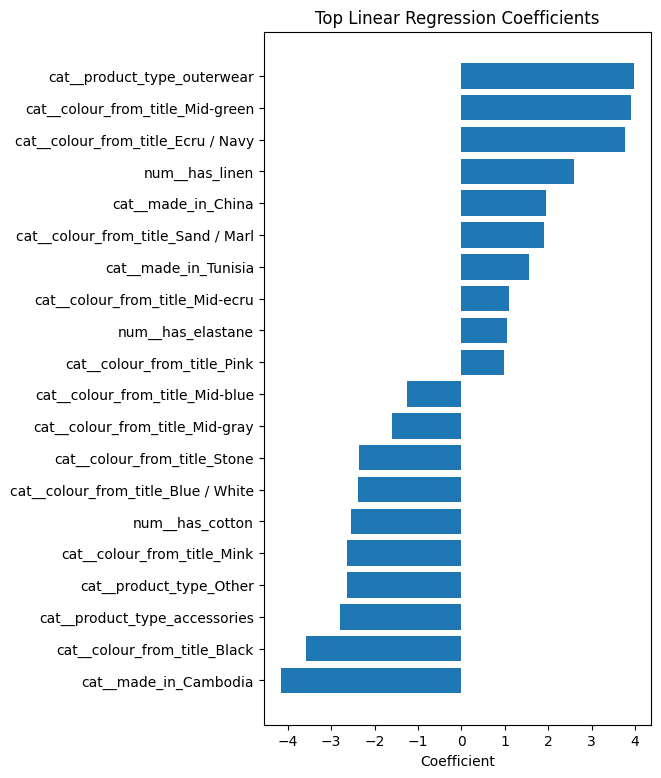

In [32]:
top_coef = coef_df.head(20).sort_values("coefficient")
plt.figure(figsize=(5,9))
plt.barh(top_coef["feature"], top_coef["coefficient"])
plt.xlabel("Coefficient")
plt.title("Top Linear Regression Coefficients")
#plt.tight_layout()
plot3 = "combined_top_coefficients.png"
#plt.savefig(plot3, dpi=200)
plt.show()

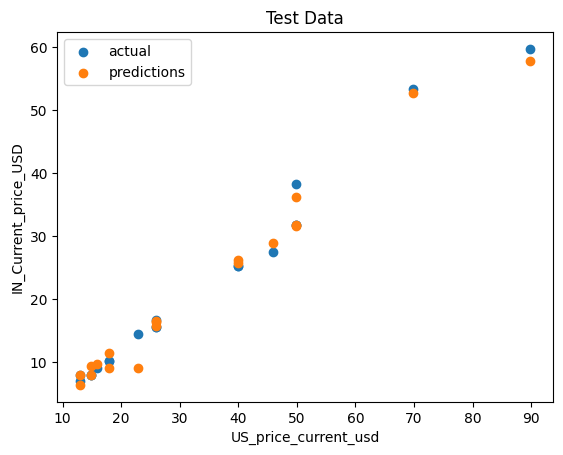

In [33]:
plt.scatter(X_test['US_price_current_usd'], y_test,label="actual")
plt.scatter(X_test['US_price_current_usd'],pred,label="predictions")
plt.xlabel("US_price_current_usd")
plt.ylabel("IN_Current_price_USD")
plt.title("Test Data")
plt.legend()

In [34]:
# 1. Transform the data using the preprocessor we already built
X_transformed = model.named_steps['preprocessor'].transform(X)

# 2. Get the clean names for all those 1s and 0s
feature_names = model.named_steps['preprocessor'].get_feature_names_out()

# 3. Turn it back into a nice looking Table (DataFrame)
# Note: X_transformed might be a "sparse matrix", so we use .toarray()
transformed_df = pd.DataFrame(
    X_transformed.toarray() if hasattr(X_transformed, "toarray") else X_transformed,
    columns=feature_names
)

# 4. Add the 'Answer' (price_gap_pct) back in so you can see it next to the clues
transformed_df['TARGET_India_current_price_usd'] = y.values

transformed_df['was_material_missing'] = transformed_df.isna().any(axis=1)
#transformed_df['Prediction'] = pred
#transformed_df['Error'] = transformed_df['Prediction'] - transformed_df['TARGET_India_current_price_usd']

print(transformed_df.columns)

# 5. Save to a CSV file!
transformed_df.to_csv(directory + "zara_KIDS_transformed_data_April_13.csv", index=False)

print("✅ Success! Your 'Robot View' dataset has been saved.")

Index(['num__US_price_current_usd', 'num__has_cotton', 'num__has_polyester',
       'num__has_viscose', 'num__has_linen', 'num__has_silk', 'num__has_wool',
       'num__has_elastane', 'num__has_leather', 'num__has_rcs', 'num__has_ocs',
       'cat__Category_GENERAL', 'cat__Category_MAN',
       'cat__colour_from_title_Beige', 'cat__colour_from_title_Black',
       'cat__colour_from_title_Blue', 'cat__colour_from_title_Blue / Gray',
       'cat__colour_from_title_Blue / White', 'cat__colour_from_title_Bluish',
       'cat__colour_from_title_Brown', 'cat__colour_from_title_Burgundy',
       'cat__colour_from_title_Ecru', 'cat__colour_from_title_Ecru / Blue',
       'cat__colour_from_title_Ecru / Navy', 'cat__colour_from_title_Gray',
       'cat__colour_from_title_Gray marl',
       'cat__colour_from_title_Light beige',
       'cat__colour_from_title_Light blue',
       'cat__colour_from_title_Lime green', 'cat__colour_from_title_Maroon',
       'cat__colour_from_title_Mauve', 'cat__colou

Cheaper country

In [35]:
df = df.sort_values('US_price_current_usd')
df = df.drop_duplicates(subset=['Product_ID'], keep='first')
print(len(df))
# print(df.head)
# df["USD_converted_INR"] = df['US_price_current_usd'] * df['exchange_rate']

print(len(df.columns))

#print("US price (USD)\tIN price (USD)")
#for i in df.index:
#  print(df.loc[i,'US_price_current_usd'], df.loc[i,'IN_price_current_usd'])

# 1. Calculate the Ratio for every single row
df['price_ratio'] = df['IN_price_current_usd'] / df['US_price_current_usd']

# 2. Group by Category to see which "Section" is cheapest in India
category_deals = df.groupby('product_type')['price_ratio'].mean().sort_values()

print("--- Average Price Ratio by Product Type (Lower is better for India) ---")
print(category_deals)

101
33
--- Average Price Ratio by Product Type (Lower is better for India) ---
product_type
accessories    0.566663
Other          0.568553
top            0.572478
bottom         0.620174
dress          0.645375
shoes          0.663070
outerwear      0.720105
Name: price_ratio, dtype: float64


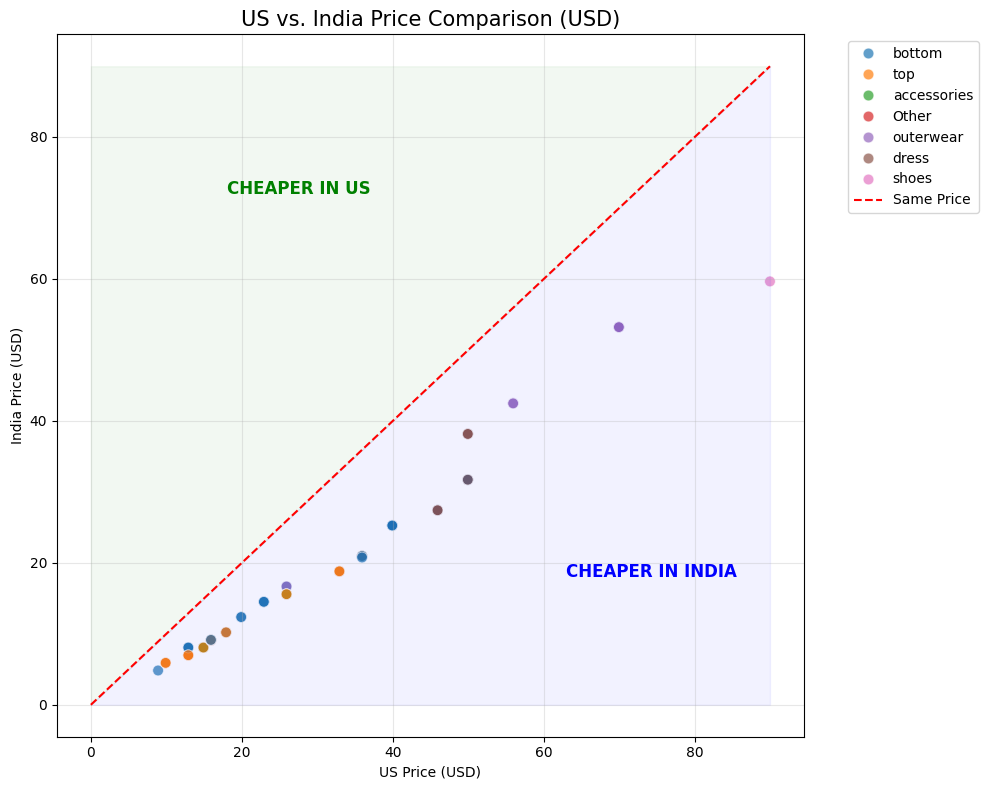

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Setup the figure
plt.figure(figsize=(10, 8))

# 2. Create the Scatter Plot
# We color by 'category' to see if certain types of clothes are outliers
sns.scatterplot(data=df, x='US_price_current_usd', y='IN_price_current_usd',
                hue='product_type', alpha=0.7, s=60)

# 3. Create the "Equality Line" (y = x)
# This line shows where the prices would be if they were exactly the same
max_price = max(df['US_price_current_usd'].max(), df['IN_price_current_usd'].max())
plt.plot([0, max_price], [0, max_price], color='red', linestyle='--', label='Same Price')

# 4. Shade the regions for instant "Bargain" detection
plt.fill_between([0, max_price], [0, max_price], max_price, color='green', alpha=0.05)
plt.fill_between([0, max_price], 0, [0, max_price], color='blue', alpha=0.05)

# 5. Add Labels & Legend
plt.text(max_price*0.2, max_price*0.8, "CHEAPER IN US", color='green', fontsize=12, fontweight='bold')
plt.text(max_price*0.7, max_price*0.2, "CHEAPER IN INDIA", color='blue', fontsize=12, fontweight='bold')

plt.title("US vs. India Price Comparison (USD)", fontsize=15)
plt.xlabel("US Price (USD)")
plt.ylabel("India Price (USD)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()

#plt.savefig('price_comparison_scatter.png')